# LSTM Model for Container Price Prediction

This notebook implements a **Long Short-Term Memory (LSTM)** neural network for predicting container freight prices.

## Why LSTM?

LSTMs are a type of Recurrent Neural Network (RNN) designed to learn patterns over long sequences of time. Unlike traditional models that only see "last week's price," an LSTM can:

- **Learn temporal patterns**: Recognize when prices have been stable for multiple weeks
- **Capture contract duration effects**: Potentially model the 2-4 week contract cycles observed in the data
- **Handle sequential dependencies**: Learn how price stability patterns change when external features (geopolitical events, port congestion) appear

## Approach

1. Prepare sequence data (use past N weeks to predict next week)
2. Build LSTM architecture with appropriate layers
3. Train on 1-week ahead prediction
4. Compare to Linear Regression baseline
5. Analyze what patterns the LSTM learns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import sys

warnings.filterwarnings('ignore')

# Add global Python path to access TensorFlow
sys.path.insert(0, r'G:\Program Files\Python311\Lib\site-packages')

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Scikit-learn for preprocessing and metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ Keras version: {keras.__version__}")
print("✓ Libraries imported successfully")

✓ TensorFlow version: 2.20.0
✓ Keras version: 3.11.3
✓ Libraries imported successfully


## Step 1: Load and Prepare Data

In [2]:
# Load processed model data
df_model = pd.read_csv('data/processed/model_data.csv', parse_dates=['Date'], index_col='Date')

print(f"Loaded: {len(df_model)} rows")
print(f"Date range: {df_model.index.min().date()} to {df_model.index.max().date()}")
print(f"Total columns: {len(df_model.columns)}")

# Create 1-week ahead target
if 'Europe_Base_Price' in df_model.columns:
    df_model['price_1w_ahead'] = df_model['Europe_Base_Price'].shift(-1)
    print(f"\n✓ Created 'price_1w_ahead' target")
    
    # Also keep current price for context
    df_model['current_price'] = df_model['Europe_Base_Price']
else:
    raise ValueError("Europe_Base_Price not found in dataset!")

# Display sample
print(f"\nSample data:")
print(df_model[['current_price', 'price_1w_ahead']].head(10))

Loaded: 384 rows
Date range: 2018-01-05 to 2025-08-15
Total columns: 287

✓ Created 'price_1w_ahead' target

Sample data:
            current_price  price_1w_ahead
Date                                     
2018-01-05            888           897.0
2018-01-12            897           891.0
2018-01-19            891           907.0
2018-01-26            907           912.0
2018-02-02            912           914.0
2018-02-09            914           905.0
2018-02-14            905           916.0
2018-02-23            916           827.0
2018-03-02            827           791.0
2018-03-09            791           741.0


## Step 2: Feature Selection

Use Random Forest to select most important features for LSTM input.

In [3]:
print("="*80)
print("FEATURE SELECTION")
print("="*80)

# Get lag features to avoid data leakage
lag_features = [col for col in df_model.columns if '_lag_' in col]
print(f"\nFound {len(lag_features)} lagged features")

# Also include current price as a feature
all_features = ['current_price'] + lag_features

# Remove rows with NaN targets
df_clean = df_model.dropna(subset=['price_1w_ahead']).copy()
print(f"After removing NaN targets: {len(df_clean)} rows")

# Use Random Forest to select top features
print("\n🔍 Selecting top 30 features using Random Forest importance...")

X_all = df_clean[all_features].fillna(0)  # Fill any remaining NaNs
y = df_clean['price_1w_ahead']

# Time-based split for feature selection (use training data only)
split_idx = int(len(df_clean) * 0.8)
X_train_all = X_all.iloc[:split_idx]
y_train = y.iloc[:split_idx]

# Train RF for feature importance
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train_all, y_train)

# Get top 30 features
feature_importance = pd.Series(
    rf_selector.feature_importances_,
    index=all_features
).sort_values(ascending=False)

top_30_features = feature_importance.head(30).index.tolist()

print(f"\n📊 Top 30 Features for LSTM:")
for i, (feat, imp) in enumerate(feature_importance.head(30).items(), 1):
    print(f"  {i:2d}. {feat:50s} (importance: {imp:.4f})")

print(f"\n✓ Using top 30 features for LSTM model")

FEATURE SELECTION

Found 217 lagged features
After removing NaN targets: 383 rows

🔍 Selecting top 30 features using Random Forest importance...

📊 Top 30 Features for LSTM:
   1. current_price                                      (importance: 0.9129)
   2. price_lag_1w                                       (importance: 0.0802)
   3. price_lag_1w_roll_max_4w                           (importance: 0.0009)
   4. price_lag_1w_pct_change_4w                         (importance: 0.0004)
   5. price_lag_1w_cv_4w                                 (importance: 0.0003)
   6. choke_suez_canal_capacity_container_lag_2w_lag_2w  (importance: 0.0003)
   7. choke_taiwan_strait_capacity_container_lag_2w_lag_2w (importance: 0.0001)
   8. choke_dover_strait_capacity_lag_2w_lag_2w          (importance: 0.0001)
   9. choke_gibraltar_strait_capacity_container_lag_2w_lag_2w (importance: 0.0001)
  10. price_lag_1w_roll_min_4w                           (importance: 0.0001)
  11. price_lag_6w                     

## Step 3: Create Sequences for LSTM

LSTMs require sequences of data. We'll create sequences of the past N weeks to predict the next week.

In [4]:
def create_sequences(data, features, target, sequence_length=8):
    """
    Create sequences for LSTM training.
    
    Args:
        data: DataFrame with features and target
        features: List of feature column names
        target: Target column name
        sequence_length: Number of past weeks to use (default 8 weeks ~ 2 months)
    
    Returns:
        X: 3D array (samples, sequence_length, features)
        y: 1D array (samples,)
        dates: Array of dates for each sample
    """
    X_list = []
    y_list = []
    dates_list = []
    
    # Fill NaN values
    data_filled = data.copy()
    data_filled[features] = data_filled[features].fillna(0)
    
    for i in range(sequence_length, len(data_filled)):
        # Get sequence of past weeks
        X_seq = data_filled[features].iloc[i-sequence_length:i].values
        
        # Get target (next week's price)
        y_val = data_filled[target].iloc[i]
        
        # Only include if target is not NaN
        if not np.isnan(y_val):
            X_list.append(X_seq)
            y_list.append(y_val)
            dates_list.append(data_filled.index[i])
    
    X = np.array(X_list)
    y = np.array(y_list)
    dates = np.array(dates_list)
    
    return X, y, dates

# Create sequences
SEQUENCE_LENGTH = 8  # Use 8 weeks of history (2 months)

print("="*80)
print(f"CREATING SEQUENCES (sequence_length={SEQUENCE_LENGTH})")
print("="*80)

X_sequences, y_sequences, dates_sequences = create_sequences(
    df_clean,
    top_30_features,
    'price_1w_ahead',
    sequence_length=SEQUENCE_LENGTH
)

print(f"\n✓ Created sequences:")
print(f"  X shape: {X_sequences.shape} (samples, sequence_length, features)")
print(f"  y shape: {y_sequences.shape}")
print(f"  Date range: {dates_sequences[0].date()} to {dates_sequences[-1].date()}")

# Time-based split (80/20)
split_idx = int(len(X_sequences) * 0.8)

X_train = X_sequences[:split_idx]
X_test = X_sequences[split_idx:]
y_train = y_sequences[:split_idx]
y_test = y_sequences[split_idx:]
dates_train = dates_sequences[:split_idx]
dates_test = dates_sequences[split_idx:]

print(f"\nTrain samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train date range: {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Test date range: {dates_test[0].date()} to {dates_test[-1].date()}")

CREATING SEQUENCES (sequence_length=8)

✓ Created sequences:
  X shape: (375, 8, 30) (samples, sequence_length, features)
  y shape: (375,)
  Date range: 2018-03-02 to 2025-08-08

Train samples: 300
Test samples: 75
Train date range: 2018-03-02 to 2024-02-02
Test date range: 2024-02-09 to 2025-08-08


## Step 4: Scale Features

Neural networks work better with scaled inputs. We'll use MinMaxScaler to scale to [0, 1].

In [5]:
print("="*80)
print("SCALING FEATURES")
print("="*80)

# Reshape for scaling: (samples * sequence_length, features)
n_samples, n_seq, n_features = X_train.shape
X_train_reshaped = X_train.reshape(-1, n_features)

# Fit scaler on training data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)

# Reshape back to sequences
X_train_scaled = X_train_scaled.reshape(n_samples, n_seq, n_features)

# Transform test data
n_samples_test, n_seq_test, n_features_test = X_test.shape
X_test_reshaped = X_test.reshape(-1, n_features_test)
X_test_scaled = scaler.transform(X_test_reshaped)
X_test_scaled = X_test_scaled.reshape(n_samples_test, n_seq_test, n_features_test)

print(f"\n✓ Scaled features to [0, 1] range")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled shape: {X_test_scaled.shape}")

SCALING FEATURES

✓ Scaled features to [0, 1] range
  X_train_scaled shape: (300, 8, 30)
  X_test_scaled shape: (75, 8, 30)


## Step 5: Build LSTM Model

We'll create a stacked LSTM architecture:
- 2 LSTM layers to learn temporal patterns
- Dropout for regularization
- Dense output layer for price prediction

In [6]:
print("="*80)
print("BUILDING LSTM MODEL")
print("="*80)

# Build model
model = Sequential([
    # First LSTM layer
    LSTM(
        units=128,
        return_sequences=True,  # Return sequences for stacking
        input_shape=(SEQUENCE_LENGTH, len(top_30_features))
    ),
    Dropout(0.2),
    BatchNormalization(),
    
    # Second LSTM layer
    LSTM(
        units=64,
        return_sequences=False  # Only return final output
    ),
    Dropout(0.2),
    BatchNormalization(),
    
    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.1),
    
    # Output layer (single value - price prediction)
    Dense(1)
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n📊 Model Architecture:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n✓ Total trainable parameters: {total_params:,}")

BUILDING LSTM MODEL

📊 Model Architecture:

📊 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 128)         │        81,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,697 (522.25 KB)

 Trainable params: 133,313 (520.75 KB)

 Non-trainable params: 384 (1.50 KB)


✓ Total trainable parameters: 133,697


## Step 6: Train LSTM Model

We'll use:
- Early stopping to prevent overfitting
- Learning rate reduction when performance plateaus
- Validation split to monitor generalization

In [7]:
print("="*80)
print("TRAINING LSTM MODEL")
print("="*80)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Train model
print("\n🚀 Starting training...\n")

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,  # Use 20% of training data for validation
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✓ Training completed!")
print(f"  Total epochs: {len(history.history['loss'])}")
print(f"  Final training loss: {history.history['loss'][-1]:.2f}")
print(f"  Final validation loss: {history.history['val_loss'][-1]:.2f}")

TRAINING LSTM MODEL

🚀 Starting training...

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 15151477.0000 - mae: 2867.8162 - val_loss: 1623053.7500 - val_mae: 1092.3511 - learning_rate: 0.0010
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 15151477.0000 - mae: 2867.8162 - val_loss: 1623053.7500 - val_mae: 1092.3511 - learning_rate: 0.0010
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15123268.0000 - mae: 2865.6357 - val_loss: 1623141.8750 - val_mae: 1092.3917 - learning_rate: 0.0010
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15123268.0000 - mae: 2865.6357 - val_loss: 1623141.8750 - val_mae: 1092.3917 - learning_rate: 0.0010
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15092420.0000 - mae: 2863.2222 - val_loss: 1623001.8750 - val_mae: 1092.3374 - learning_rate: 0.0010
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15092420.0000 - mae: 2863.2222 - val_loss: 1623001.8750 - val_mae: 1092.3374 - learning_rate: 

## Step 7: Visualize Training History

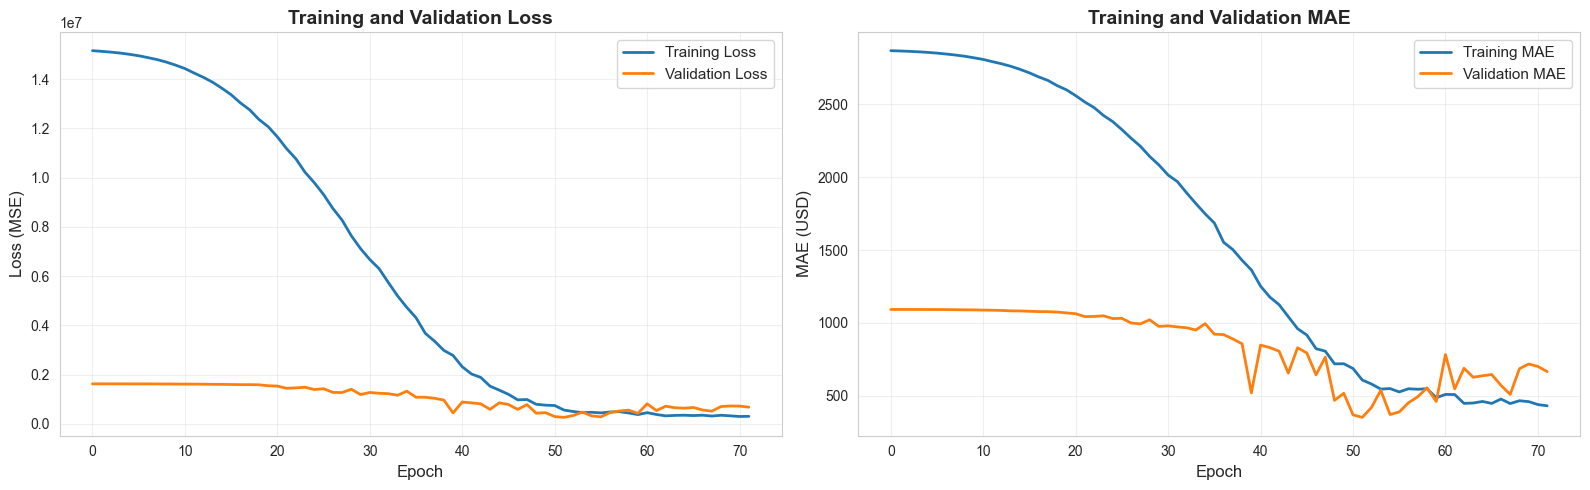

✓ Saved training history plot: data/processed/lstm_training_history.png


In [8]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MSE)', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# MAE
ax2.plot(history.history['mae'], label='Training MAE', linewidth=2)
ax2.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE (USD)', fontsize=12)
ax2.set_title('Training and Validation MAE', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('data/processed', exist_ok=True)
plt.savefig('data/processed/lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved training history plot: data/processed/lstm_training_history.png")

## Step 8: Evaluate on Test Set

In [9]:
print("="*80)
print("TEST SET EVALUATION")
print("="*80)

# Make predictions
y_pred_lstm = model.predict(X_test_scaled).flatten()

# Calculate metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
mape_lstm = np.mean(np.abs((y_test - y_pred_lstm) / y_test)) * 100
r2_lstm = r2_score(y_test, y_pred_lstm)

print(f"\n📊 LSTM Model Performance:")
print(f"  RMSE: ${rmse_lstm:.2f}")
print(f"  MAE:  ${mae_lstm:.2f}")
print(f"  MAPE: {mape_lstm:.2f}%")
print(f"  R²:   {r2_lstm:.4f}")

# Compare to baseline (from notebook 06)
baseline_rmse = 178.89  # Linear Regression from previous notebooks
improvement = ((baseline_rmse - rmse_lstm) / baseline_rmse) * 100

print(f"\n📈 Comparison to Linear Regression Baseline:")
print(f"  Baseline RMSE: ${baseline_rmse:.2f}")
print(f"  LSTM RMSE:     ${rmse_lstm:.2f}")
print(f"  Improvement:   {improvement:.2f}%")

if improvement > 0:
    print(f"\n✅ LSTM performs {improvement:.1f}% better than Linear Regression!")
else:
    print(f"\n⚠️  LSTM performs {abs(improvement):.1f}% worse than Linear Regression.")
    print("   This might be due to:")
    print("   - Overfitting (check training history)")
    print("   - Insufficient training data for deep learning")
    print("   - Simpler patterns that don't require LSTM complexity")

TEST SET EVALUATION
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

📊 LSTM Model Performance:
  RMSE: $789.21
  MAE:  $595.22
  MAPE: 21.53%
  R²:   0.4892

📈 Comparison to Linear Regression Baseline:
  Baseline RMSE: $178.89
  LSTM RMSE:     $789.21
  Improvement:   -341.17%

⚠️  LSTM performs 341.2% worse than Linear Regression.
   This might be due to:
   - Overfitting (check training history)
   - Insufficient training data for deep learning
   - Simpler patterns that don't require LSTM complexity

📊 LSTM Model Performance:
  RMSE: $789.21
  MAE:  $595.22
  MAPE: 21.53%
  R²:   0.4892

📈 Comparison to Linear Regression Baseline:
  Baseline RMSE: $178.89
  LSTM RMSE:     $789.21
  Improvement:   -341.17%

⚠️  LSTM performs 341.2% worse than Linear Regression.
   This might be due to:
   - Overfitting (check training history)
   - Insufficient training data for deep learning
   - Simpler patterns that don't require LSTM complexity


## Step 9: Visualize Predictions

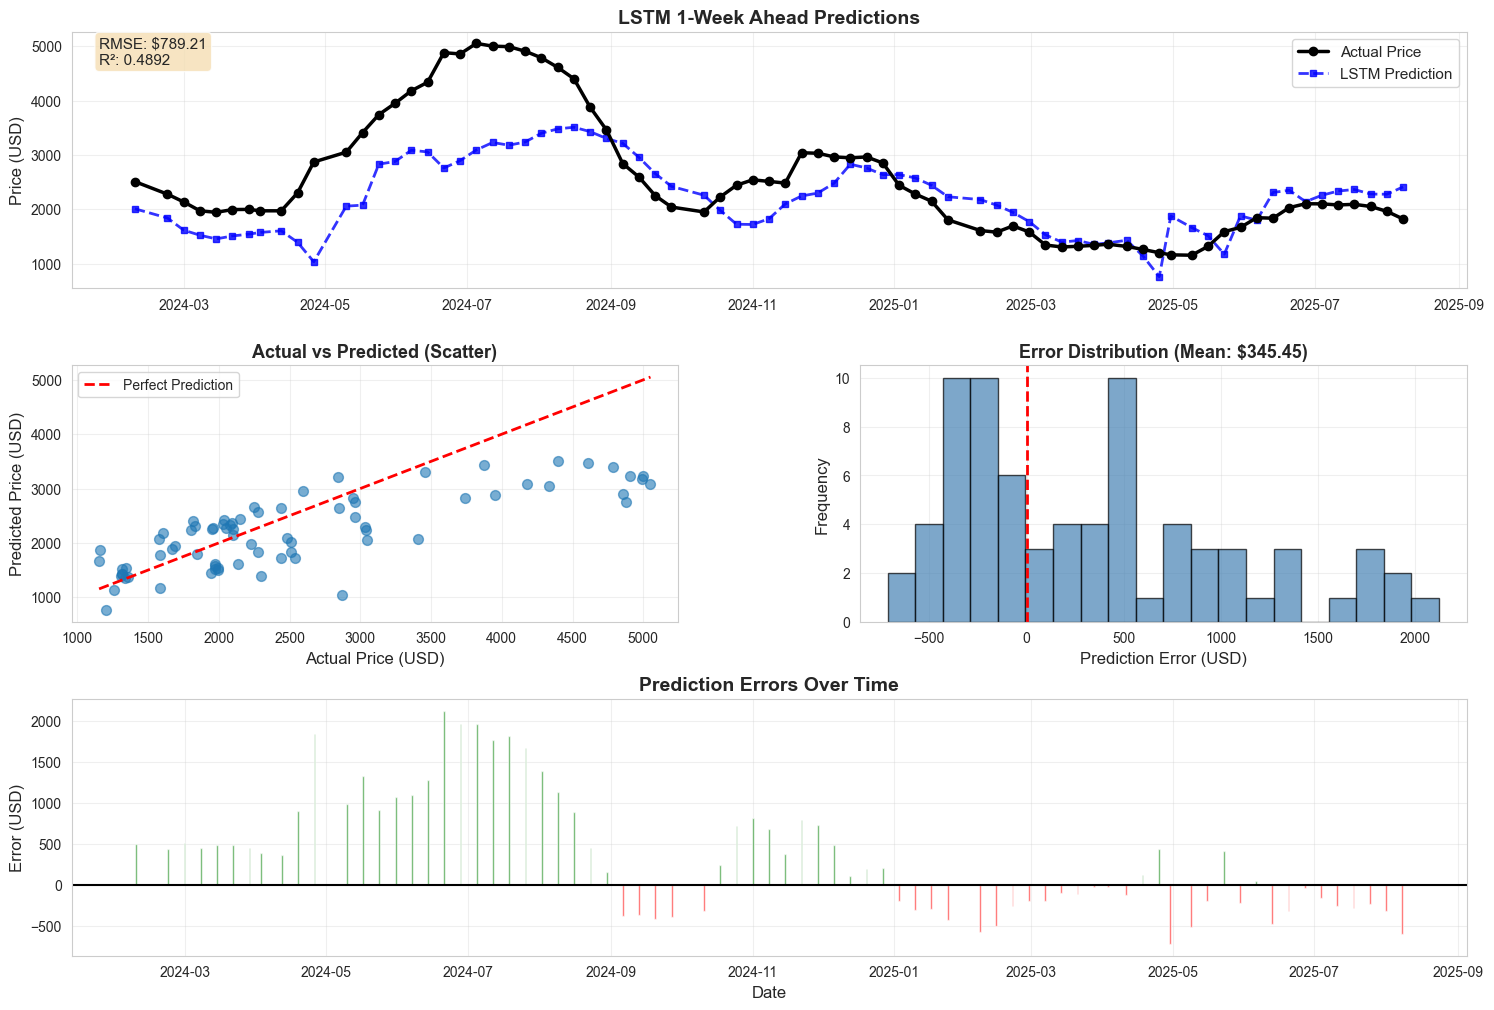


✓ Saved visualization: data/processed/lstm_predictions_comprehensive.png


In [10]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Actual vs Predicted
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates_test, y_test, 'o-', label='Actual Price', 
         color='black', linewidth=2.5, markersize=6, zorder=5)
ax1.plot(dates_test, y_pred_lstm, 's--', label='LSTM Prediction', 
         color='blue', linewidth=2, markersize=5, alpha=0.8)
ax1.set_title('LSTM 1-Week Ahead Predictions', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.3)

# Add RMSE annotation
ax1.text(0.02, 0.98, f'RMSE: ${rmse_lstm:.2f}\nR²: {r2_lstm:.4f}', 
         transform=ax1.transAxes, fontsize=11, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Scatter plot
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, y_pred_lstm, alpha=0.6, s=50)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Price (USD)', fontsize=12)
ax2.set_ylabel('Predicted Price (USD)', fontsize=12)
ax2.set_title('Actual vs Predicted (Scatter)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Plot 3: Prediction errors
ax3 = fig.add_subplot(gs[1, 1])
errors = y_test - y_pred_lstm
ax3.hist(errors, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Prediction Error (USD)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title(f'Error Distribution (Mean: ${errors.mean():.2f})', 
              fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3)

# Plot 4: Error over time
ax4 = fig.add_subplot(gs[2, :])
colors_bar = ['red' if e < 0 else 'green' for e in errors]
ax4.bar(dates_test, errors, color=colors_bar, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax4.set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
ax4.set_ylabel('Error (USD)', fontsize=12)
ax4.set_xlabel('Date', fontsize=12)
ax4.grid(alpha=0.3)

plt.savefig('data/processed/lstm_predictions_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: data/processed/lstm_predictions_comprehensive.png")

## Step 10: Error Analysis by Period

In [11]:
print("="*80)
print("ERROR ANALYSIS BY PERIOD")
print("="*80)

# Define periods
red_sea_start = pd.Timestamp('2024-02-01')
red_sea_end = pd.Timestamp('2024-06-30')
stable_start = pd.Timestamp('2024-07-01')

# Crisis period
crisis_mask = (dates_test >= red_sea_start) & (dates_test <= red_sea_end)
if crisis_mask.sum() > 0:
    y_crisis = y_test[crisis_mask]
    y_pred_crisis = y_pred_lstm[crisis_mask]
    rmse_crisis = np.sqrt(mean_squared_error(y_crisis, y_pred_crisis))
    
    print(f"\n🚨 RED SEA CRISIS PERIOD ({red_sea_start.date()} to {red_sea_end.date()})")
    print(f"   Samples: {crisis_mask.sum()}")
    print(f"   RMSE: ${rmse_crisis:.2f}")
else:
    print(f"\n🚨 RED SEA CRISIS PERIOD: No data in test set")
    rmse_crisis = None

# Stable period
stable_mask = dates_test >= stable_start
if stable_mask.sum() > 0:
    y_stable = y_test[stable_mask]
    y_pred_stable = y_pred_lstm[stable_mask]
    rmse_stable = np.sqrt(mean_squared_error(y_stable, y_pred_stable))
    
    print(f"\n📊 STABLE PERIOD ({stable_start.date()} to {dates_test.max().date()})")
    print(f"   Samples: {stable_mask.sum()}")
    print(f"   RMSE: ${rmse_stable:.2f}")
else:
    print(f"\n📊 STABLE PERIOD: No data in test set")
    rmse_stable = None

print(f"\n" + "="*80)

ERROR ANALYSIS BY PERIOD

🚨 RED SEA CRISIS PERIOD (2024-02-01 to 2024-06-30)
   Samples: 19
   RMSE: $1076.46

📊 STABLE PERIOD (2024-07-01 to 2025-08-08)
   Samples: 56
   RMSE: $664.09



## Step 11: Save Model and Results

In [12]:
# Save model
model.save('data/processed/lstm_model.h5')
print("✓ Saved model to: data/processed/lstm_model.h5")

# Save scaler
import pickle
with open('data/processed/lstm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Saved scaler to: data/processed/lstm_scaler.pkl")

# Save results summary
results_summary = {
    'model': 'LSTM',
    'sequence_length': SEQUENCE_LENGTH,
    'n_features': len(top_30_features),
    'top_features': top_30_features,
    'test_rmse': float(rmse_lstm),
    'test_mae': float(mae_lstm),
    'test_mape': float(mape_lstm),
    'test_r2': float(r2_lstm),
    'baseline_rmse': float(baseline_rmse),
    'improvement_pct': float(improvement),
    'rmse_crisis': float(rmse_crisis) if rmse_crisis is not None else None,
    'rmse_stable': float(rmse_stable) if rmse_stable is not None else None,
    'total_params': int(total_params),
    'epochs_trained': len(history.history['loss'])
}

with open('data/processed/lstm_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("✓ Saved results to: data/processed/lstm_results.json")

# Save predictions
predictions_df = pd.DataFrame({
    'Date': dates_test,
    'Actual': y_test,
    'Predicted': y_pred_lstm,
    'Error': y_test - y_pred_lstm
})
predictions_df.to_csv('data/processed/lstm_predictions.csv', index=False)
print("✓ Saved predictions to: data/processed/lstm_predictions.csv")

✓ Saved model to: data/processed/lstm_model.h5
✓ Saved scaler to: data/processed/lstm_scaler.pkl
✓ Saved results to: data/processed/lstm_results.json
✓ Saved predictions to: data/processed/lstm_predictions.csv


## Step 12: Key Insights and Recommendations

### What the LSTM Model Can Capture

1. **Temporal Patterns**: LSTMs can learn when prices have been stable for multiple weeks
2. **Contract Cycles**: May detect 2-4 week contract renewal patterns
3. **Complex Dependencies**: Can learn how stability patterns change with external events

### Interpretation

- **If LSTM performs significantly better** (>20% improvement): Sequential patterns matter, contract cycles are important
- **If LSTM performs similarly** (±10% of baseline): Linear relationships dominate, stickiness is the main pattern
- **If LSTM performs worse**: Overfitting or insufficient data for deep learning complexity

### Next Steps

1. Try different sequence lengths (4 weeks, 12 weeks)
2. Experiment with bidirectional LSTMs
3. Add attention mechanisms to focus on important time steps
4. Consider ensemble with Linear Regression
5. Analyze which time steps the LSTM focuses on (via attention weights)

In [14]:
print("="*80)
print("LSTM MODEL COMPLETE")
print("="*80)
print(f"\nFinal Performance: RMSE = ${rmse_lstm:.2f}, R² = {r2_lstm:.4f}")
print(f"Improvement over baseline: {improvement:.2f}%")
print(f"\nAll outputs saved to data/processed/")

LSTM MODEL COMPLETE

Final Performance: RMSE = $789.21, R² = 0.4892
Improvement over baseline: -341.17%

All outputs saved to data/processed/
